# Module 3 Assignment Questions
### ADS500B
### Jordan Blackman

In [85]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

## 1. The dataset “weights.tsv” contains weight values (in pounds) for 20 people: 164, 158, 172, 153, 144, 156, 189, 163, 134, 159, 143, 176, 177, 162, 141, 151, 182, 185, 171, 152. 
### 1.1. Import the data from the file weights.tsv into a Pandas Series object in Python. NB: This is different from a Pandas Dataframe object. (4 points) 


In [86]:
weights_df = pd.read_csv("weights.tsv", sep='\t', header=None)
weights_series = weights_df[0]
print(type(weights_series))

<class 'pandas.core.series.Series'>


### 1.2. Create a new series object with weights converted to kilograms from pounds (1 pound = 0.453592 kilograms). Round the results to two decimal places. (4 points) 

In [87]:
weights_series_kg = weights_series * 0.453592
weights_series_kg.head()

0    74.389088
1    71.667536
2    78.017824
3    69.399576
4    65.317248
Name: 0, dtype: float64

### 1.3. Find the mean, median, and standard deviation of both series objects using Pandas functions. (4 points) 

In [88]:
## Note. the median is the 50% percentile
print("Descriptive statistics of the original weights series object")
print(weights_series.describe())
print("-------------------------------------------------------------------")
print("Descriptive statistics of the converted (KG) weights series object")
print(weights_series_kg.describe())

Descriptive statistics of the original weights series object
count     20.000000
mean     161.600000
std       15.449067
min      134.000000
25%      151.750000
50%      160.500000
75%      173.000000
max      189.000000
Name: 0, dtype: float64
-------------------------------------------------------------------
Descriptive statistics of the converted (KG) weights series object
count    20.000000
mean     73.300467
std       7.007573
min      60.781328
25%      68.832586
50%      72.801516
75%      78.471416
max      85.728888
Name: 0, dtype: float64


### 1.4. Plot a histogram of weight (in kilograms) using matplotlib library with 10 bins. (4 points) 

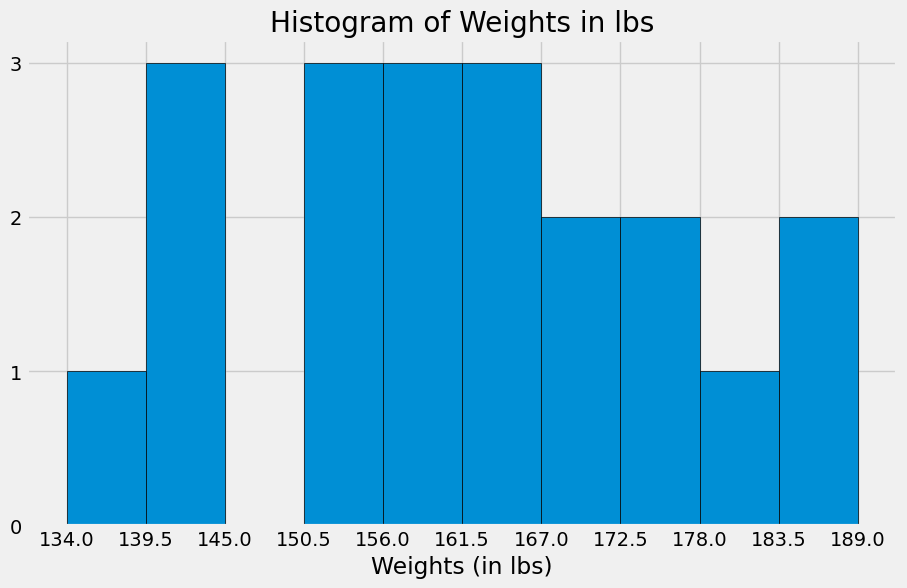

In [89]:
plt.figure(figsize=(10,6))
plt.style.use('fivethirtyeight')
counts, bins, patches = plt.hist(weights_series, bins=10, edgecolor='black')
plt.title("Histogram of Weights in lbs")
plt.xlabel("Weights (in lbs)")
plt.yticks(np.arange(0, 4, step=1))
plt.xticks(bins.round(1))
plt.show()

## 2. For this problem statement, you are given a dataset named “boston.csv”. This dataset contains information collected by the US Census Service concerning housing in the areas of Boston, Mass. The data was originally published by Harrison, D., & Rubinfeld, D.L. (1978). Hedonic prices and the demand for clean air. Journal of Environmental Economics and Management,5,81–102. 
### 2.1 Import the dataset “boston.csv” into a Pandas dataframe and obtain the number of rows and columns for the dataframe. (3 points) 

In [90]:
boston = pd.read_csv("boston.csv")
print(type(boston))
print(boston.head())
data_shape = boston.shape
print(f"The data set has {data_shape[0]} rows and {data_shape[1]} columns.")


<class 'pandas.core.frame.DataFrame'>
      CRIM    ZN  NDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0  2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0  7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0  7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0  2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0  2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

   LSTAT  MEDV  
0   4.98  24.0  
1   9.14  21.6  
2   4.03  34.7  
3   2.94  33.4  
4   5.33  36.2  
The data set has 506 rows and 13 columns.


### 2.2. What is the owner-occupied home value (MEDV) for the lowest nitric oxide concentration (NOX) from the dataframe? (3 points) 

In [91]:
print(boston.nsmallest(1, 'NOX')['MEDV'].iloc[0])

20.1


### 2.3. Create a boxplot of per capita crime rate (CRIM) using Matplotlib. Obtain the interquartile range for crime rate (CRIM) using Pandas functions. (4 points) 

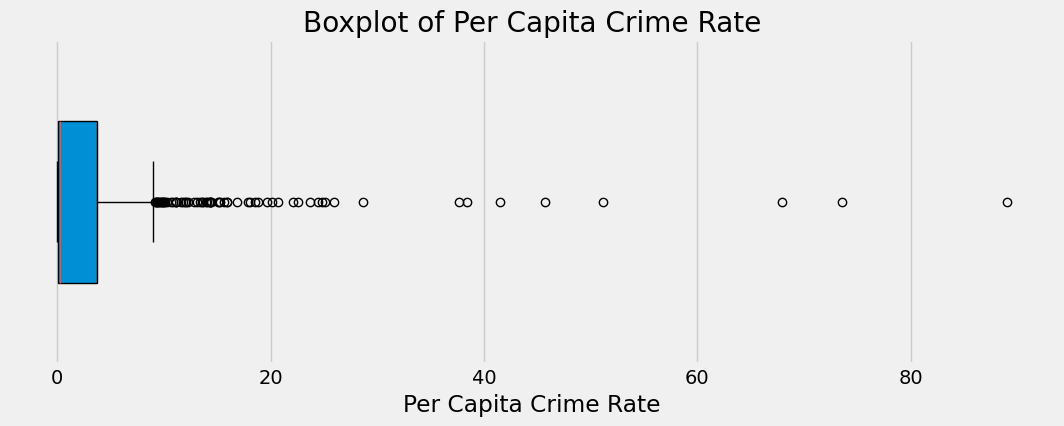

The interquartile range of per capita crime rate is 3.5950375


In [92]:
plt.figure(figsize=(12, 4))
plt.boxplot(boston['CRIM'], vert=False, patch_artist=True, widths=0.5)
plt.title("Boxplot of Per Capita Crime Rate")
plt.xlabel("Per Capita Crime Rate")
plt.yticks([])
plt.show()

IQR = boston['CRIM'].quantile(0.75) - boston['CRIM'].quantile(0.25)
print(f"The interquartile range of per capita crime rate is {IQR}")

### 2.4. Subset all columns of the dataframe for rows with outliers of crime rate into a new dataframe. Compare the mean of AGE between the two dataframes with respect to crime rate, what do you interpret? (Hint: Outliers exist 1.5 times of interquartile range above third quartile and below first quartile) (4 points) 

In [93]:
boston_mean_age = round(boston['AGE'].mean(), 2)
boston_mean_crime = round(boston['CRIM'].mean(), 2)
upper_crime_limit = boston['CRIM'].quantile(0.75) + (1.5 * IQR)
lower_crime_limit = boston['CRIM'].quantile(0.25) - (1.5 * IQR)
print(f"Lower crime limit = {round(lower_crime_limit, 2)}")

## I only filtered for the upper crime limit because the lower crime limit is below zero
## A per capita crime rate cannot be below zero, therefore the filter is not needed in this case
boston_crime_outliers = boston[boston['CRIM'] > upper_crime_limit]
boston_crime_outliers_mean_age = round(boston_crime_outliers['AGE'].mean(), 2)
boston_crime_outliers_mean_crime = round(boston_crime_outliers['CRIM'].mean(), 2)

boston_outliers_comp = {'Average Age' : [boston_mean_age, boston_crime_outliers_mean_age],
                        'Average Per Capita Crime Rage' : [boston_mean_crime, boston_crime_outliers_mean_crime]
                        }
row_names = ['Original Data', 'Outliers']
comp_df = pd.DataFrame(boston_outliers_comp, index=row_names)
comp_df

Lower crime limit = -5.31


,Average Age,Average Per Capita Crime Rage
Original Data,68.57,3.61
Outliers,94.23,19.71


The average per capita crime rate is higher in the dataset filtered for outliers, which is unsurprising. Age represents the proportion of owner-occupied units built prior to 1940. This indicates that higher average crime rate per capita is associated with older residential communities.

### 2.5. Create scatterplot between distances to employment centers (DIS) and nitric oxide levels (NOX). Obtain correlation index between the two columns and interpret their relation. (4 points) 

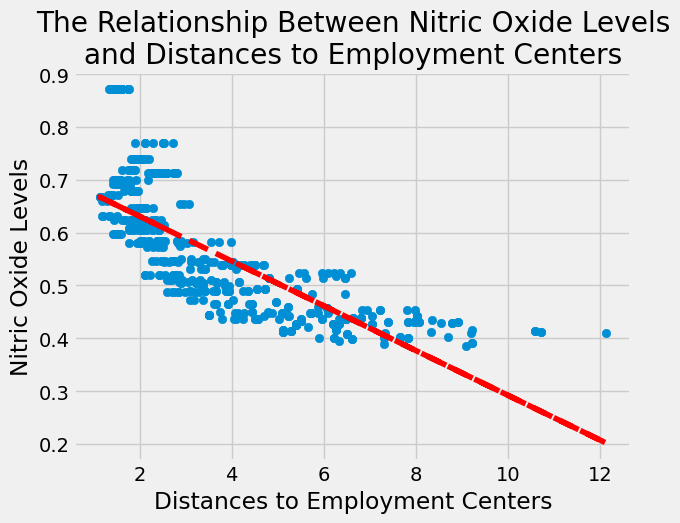

-0.769


In [111]:
x = boston['DIS']
y = boston['NOX']

plt.scatter(x, y)
plt.title("The Relationship Between Nitric Oxide Levels\nand Distances to Employment Centers")
plt.xlabel("Distances to Employment Centers")
plt.ylabel("Nitric Oxide Levels")
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x,p(x),"r--")
plt.show()

correl = np.corrcoef(x, y)
print(round(correl[0,1],3))

There exists a negative relationship between nitric oxide levels and distances to employment centers because the correlation coefficient is -.769. The relationship is not perfectly linear, the scatter plot follows a 1/X curve, where values close to X = 0 on the right side get larger, while large values of X get increasingly small, with a horizontal asymptote just below 0.4. To ensure our data follows a linear trend, non-linear transforms methods can be used, as shown below.

-0.832
-0.808
-0.86


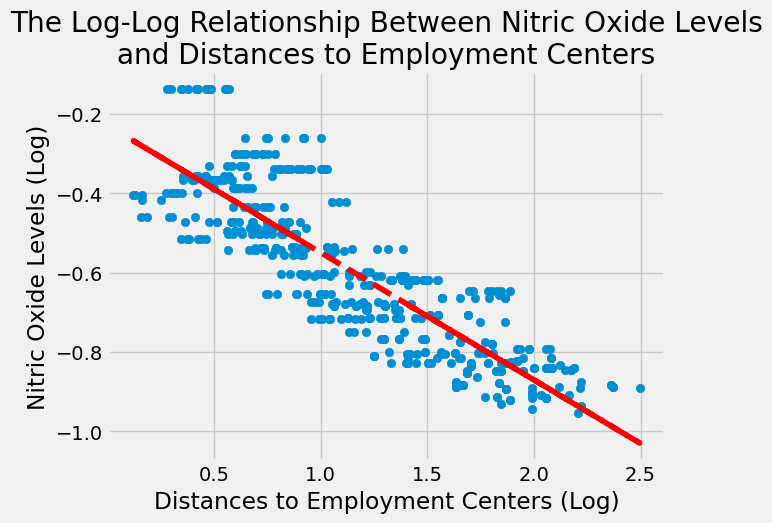

In [110]:
dis_log = np.log(boston['DIS'])
nox_log = np.log(boston['NOX'])

correl_dis_log = np.corrcoef(dis_log, boston['NOX'])
print(round(correl_dis_log[0,1], 3))

correl_nox_log = np.corrcoef(nox_log, boston['DIS'])
print(round(correl_nox_log[0,1], 3))

correl_log_log = np.corrcoef(dis_log, nox_log)
print(round(correl_log_log[0,1], 3))

plt.scatter(dis_log, nox_log)
plt.title("The Log-Log Relationship Between Nitric Oxide Levels\nand Distances to Employment Centers")
plt.xlabel("Distances to Employment Centers (Log)")
plt.ylabel("Nitric Oxide Levels (Log)")
z = np.polyfit(dis_log, nox_log, 1)
p = np.poly1d(z)
plt.plot(dis_log,p(dis_log),"r--")
plt.show()

Performing a log-log transform yields the strongest correlation coefficient (-.86), and the scatter plot yields a much more clear linear relationship.

### 2.6. Similarly, create a scatterplot between highway accessibility index (RAD) and property tax rate (TAX). Obtain correlation index, compare it to the scatter-plot, and interpret the relation between RAD and TAX. Take appropriate action on the data based on your observation. (6 points) 

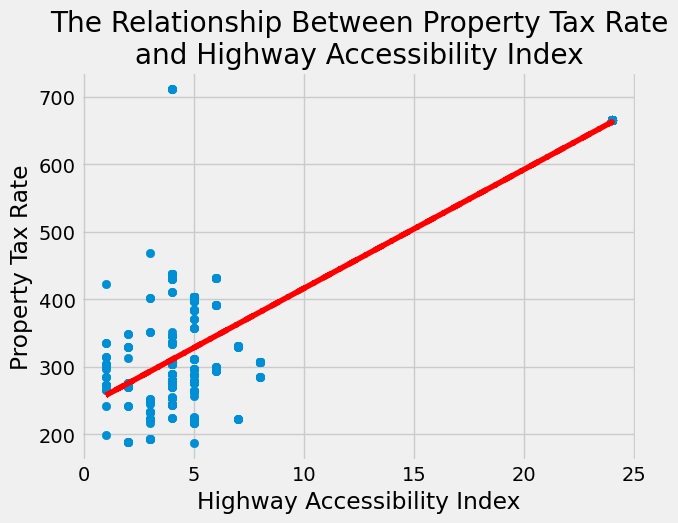

0.91


In [117]:
x = boston['RAD']
y = boston['TAX']

plt.scatter(x, y)
plt.title("The Relationship Between Property Tax Rate\nand Highway Accessibility Index")
plt.xlabel("Highway Accessibility Index")
plt.ylabel("Property Tax Rate")
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x,p(x),"r--")
plt.show()

correl = np.corrcoef(x, y)
print(round(correl[0,1],3))

Outliers are clearly inflating the correlation and changing the slope of the line meaningfully, these points should be removed.

137


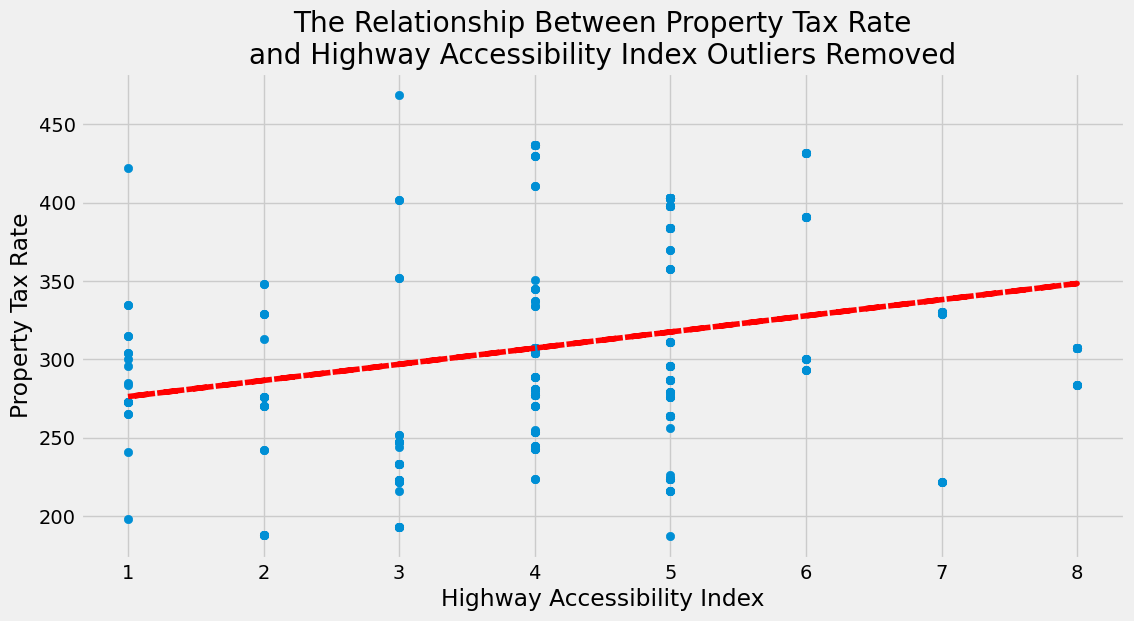

0.25


In [121]:
tax_IQR = boston['TAX'].quantile(0.75) - boston['TAX'].quantile(0.25)
upper_tax_limit = boston['TAX'].quantile(0.75) + (1.5 * tax_IQR)
lower_tax_limit = boston['TAX'].quantile(0.25) - (1.5 * tax_IQR)

rad_IQR = boston['RAD'].quantile(0.75) - boston['RAD'].quantile(0.25)
upper_rad_limit = boston['RAD'].quantile(0.75) + (1.5 * rad_IQR)
lower_rad_limit = boston['RAD'].quantile(0.25) - (1.5 * rad_IQR)

# boston_tax_and_rad_outliers_removed = boston[(boston['TAX'] < upper_tax_limit)
#                                              & (boston['TAX'] > lower_tax_limit)
#                                              & (boston['RAD'] < upper_rad_limit)
#                                              & (boston['RAD'] > lower_rad_limit)]

# print(boston['TAX'].describe())
# print(upper_tax_limit)
# print(lower_tax_limit)
# print(boston['RAD'].describe())
# print(upper_rad_limit)
# print(lower_rad_limit)

boston_tax_and_rad_large_values_removed = boston[(boston['TAX'] < boston['TAX'].max())
                                                & (boston['RAD'] < boston['RAD'].max())]

print(boston.shape[0] - boston_tax_and_rad_large_values_removed.shape[0])
x = boston_tax_and_rad_large_values_removed['RAD']
y = boston_tax_and_rad_large_values_removed['TAX']

plt.figure(figsize=(12,6))
plt.scatter(x, y)
plt.title('The Relationship Between Property Tax Rate\nand Highway Accessibility Index Outliers Removed')
plt.xlabel("Highway Accessibility Index")
plt.ylabel("Property Tax Rate")
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x,p(x),"r--")
plt.show()

correl = np.corrcoef(x, y)
print(round(correl[0,1],3))

After removing 137 rows (506 minus 369), there still exists a positive correlation between property tax rate and highway accessibility index, but the correlation is a much weaker relationship at .25. 

## 3.	We will be using the “tips” dataset from seaborn package for this problem statement. This dataset contains information about restaurant bills and tips made by people classified by their gender along with few other attributes which are self-explanatory. You can import this dataset into a pandas dataframe as follows: 
### 3.1. Calculate percentage of tip amounts for bill totals, rounded to two decimal places and create a new column “tip_percent” in the same dataframe. (3 points)

In [123]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### 3.2. For what days in the week do we have the data, and which day has the highest bill mean? (Hint: lookup for “groupby” in pandas documentation) (3 points)

### 3.3. Are there more dinners or lunches? Create a dataframe with this data. Are there more smokers during lunches or dinners? Create another dataframe with this data. Join the two dataframes by time of day and calculate the percent of smokers at lunch and dinner. Compare the results. (6 points) 

### 3.4. Using the boxplot function from seaborn package, create plots on “tip” column for Male and Female from “sex” column. Compare the boxplots and provide your interpretation on outliers between males and females. (4 points) 

### 3.5. Create the same boxplots as above for “tip_percent” and “sex”, for tip percent below 70. Now compare the boxplots between male and female, which boxplot has more outliers and which one is more symmetric? (4 points) 

## 4.	For this last problem statement, you will work on the “avocado.csv” dataset which contains information related to avocado sales across multiple regions/cities over the years 2015 to 2018 organized by date. The data contains 10 columns which are self explanatory. 
 
### 4.1. Import the dataset file into a Pandas dataframe and identify the count of missing values per column. Handle missing values based on column type and explain your reasons behind selecting appropriate techniques. (8 points) 


### 4.2. Convert the fields Type, Year and Region to categorical data type and subset the dataframe to exclude region “TotalUS” and “West” and sort the dataframe by date in ascending order. Is the mean price of an avocado higher in 2017 compared to 2016? (4 points) 

### 4.3. Using the dataframe created in the previous step, sum up the total volume of avocado sales by the existing region column and create a horizontal bar plot using Matplotlib. Which region has the highest sales of avocados by volume? Subset the data for that region, create a histogram of mean price and interpret it. Obtain the correlation index between mean price and total volume for that state, what do you find? (6 points) 

### 4.4. Considering the following timeline plot of avocado sales by volume, which month consistently has the highest volume of sales every year? In general, what could be some possible reasons driving this surge in sales? (2 points) 